**SVM Classifier**

Equation of the Hyperplane:

**y = wx - b**

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

In [2]:
import numpy as np

In [21]:
class SVM_classifier():
  # initiating the hyperparameters
  def __init__(self, learning_rate=0.001, no_of_iterations=10000, lambda_parameter=0.01):

    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations
    self.lambda_parameter = lambda_parameter

  # fitting the dataset to SVM Classifier
  def fit(self, X, Y):

    # m  --> number of Data points --> number of rows
    # n  --> number of input features --> number of columns
    self.m, self.n = X.shape
    # initiating the weight value and bias value

    self.w = np.zeros(self.n)

    self.b = 0

    self.X = X

    self.Y = Y

    # implementing Gradient Descent algorithm for Optimization
    for i in range(self.no_of_iterations):
      self.update_weights()
      
  # function for updating the weight and bias value
  def update_weights(self):
    # label encoding
    y_label = np.where(self.Y <= 0, -1, 1)

    # gradients ( dw, db)
    for index, x_i in enumerate(self.X):
      condition = y_label[index] * (np.dot(x_i, self.w) - self.b) >= 1
      if (condition == True):
        dw = 2 * self.lambda_parameter * self.w
        db = 0
      else:
        dw = 2 * self.lambda_parameter * self.w - np.dot(x_i, y_label[index])
        db = y_label[index]
      self.w = self.w - self.learning_rate * dw
      self.b = self.b - self.learning_rate * db

  # predict the label for a given input value
  def predict(self, X):
    output = np.dot(X, self.w) - self.b
    predicted_labels = np.sign(output)
    y_hat = np.where(predicted_labels <= -1, 0, 1)
    return y_hat
  def decision_function(self, X):
    return np.dot(X, self.w) - self.b

In [22]:
from sklearn.datasets import make_classification
import seaborn as sns
import pandas as pd
X , y = make_classification(n_samples=1000 , n_classes=2 , random_state=42 , n_features=2 , n_clusters_per_class=2,n_redundant=0 , class_sep=1.5)

<Axes: xlabel='0', ylabel='1'>

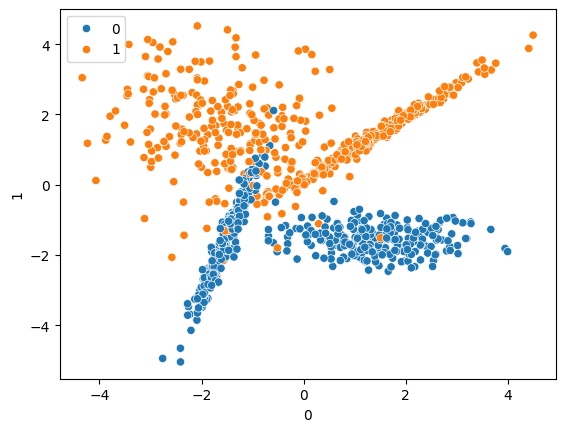

In [23]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [24]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=12)

In [25]:
model_fs = SVM_classifier()
model_fs.fit(X_train,y_train)

In [26]:
y_pred_fs = model_fs.predict(X_test)

In [27]:
from sklearn.metrics import classification_report , confusion_matrix

print(classification_report(y_test,y_pred_fs))
print(confusion_matrix(y_test,y_pred_fs))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       167
           1       0.87      0.96      0.91       133

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300

[[148  19]
 [  5 128]]


In [28]:
from sklearn.svm import SVC 
svc = SVC(kernel='linear')
svc.fit(X_train,y_train)
y_pred_SVC = svc.predict(X_test)

In [29]:
from sklearn.metrics import classification_report , confusion_matrix

print(classification_report(y_test,y_pred_SVC))
print(confusion_matrix(y_test,y_pred_SVC))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       167
           1       0.87      0.96      0.91       133

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300

[[148  19]
 [  5 128]]


In [30]:
print('*'*55)
print('SVC MODEL metrics -> \n',classification_report(y_test,y_pred_SVC),'\n',confusion_matrix(y_test,y_pred_SVC))
print('*'*55)
print('MODEL FROM SCRATCH -> \n',classification_report(y_test,y_pred_fs),'\n',confusion_matrix(y_test,y_pred_fs))

*******************************************************
SVC MODEL metrics -> 
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       167
           1       0.87      0.96      0.91       133

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300
 
 [[148  19]
 [  5 128]]
*******************************************************
MODEL FROM SCRATCH -> 
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       167
           1       0.87      0.96      0.91       133

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300
 
 [[148  19]
 [  5 128]]


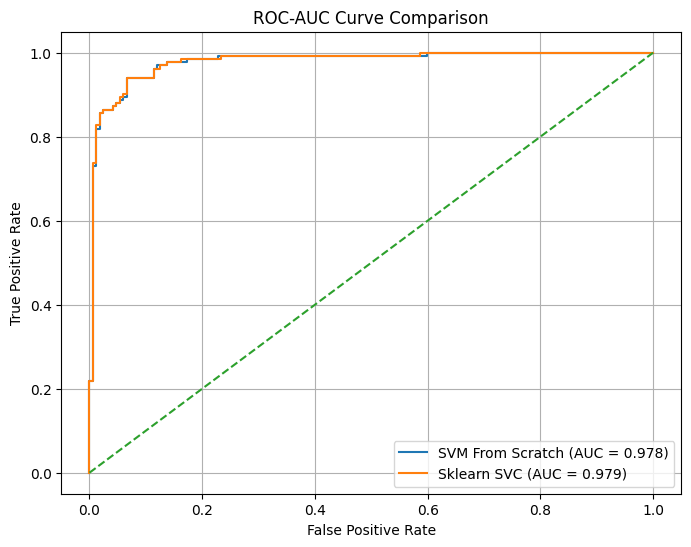

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_scores_fs = model_fs.decision_function(X_test)

y_scores_svc = svc.decision_function(X_test)

# ROC for From Scratch Model
fpr_fs, tpr_fs, thresholds_fs = roc_curve(y_test, y_scores_fs)
roc_auc_fs = auc(fpr_fs, tpr_fs)

# ROC for sklearn SVC
fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_scores_svc)
roc_auc_svc = auc(fpr_svc, tpr_svc)


plt.figure(figsize=(8,6))

plt.plot(fpr_fs, tpr_fs,
         label=f'SVM From Scratch (AUC = {roc_auc_fs:.3f})')

plt.plot(fpr_svc, tpr_svc,
         label=f'Sklearn SVC (AUC = {roc_auc_svc:.3f})')

# Random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()